In [3]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib  import pyplot as plt 
%matplotlib inline

In [9]:
df = pd.read_csv('../datasets/Kmeans_Clustering_Data.csv')
df.head()

,Name,Age,Income ($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


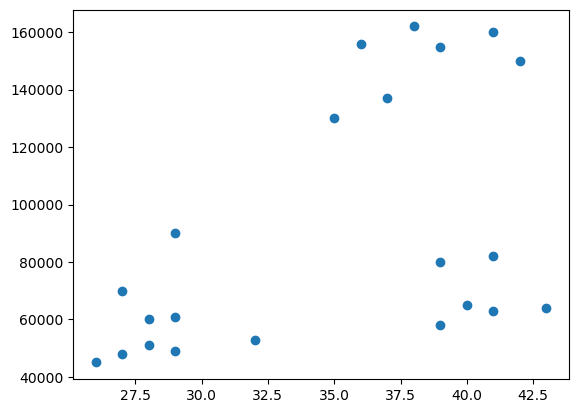

In [11]:
plt.scatter(df['Age'], df['Income ($)'])

In [13]:
km = KMeans(n_clusters = 3)
km

KMeans(n_clusters=3)

In [15]:
y_predicted = km.fit_predict(df[['Age', 'Income ($)']])
y_predicted

C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0])

In [19]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income ($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


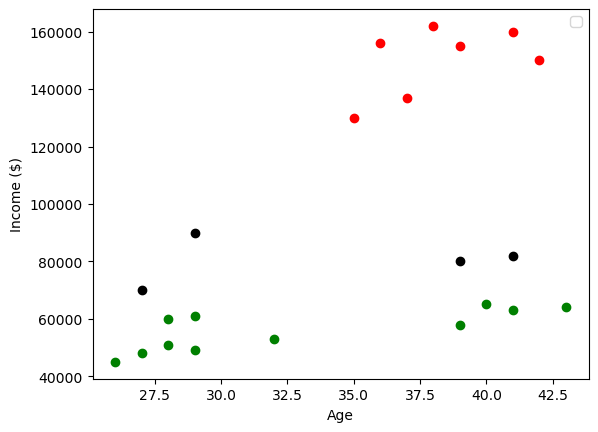

In [23]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age, df1['Income ($)'], color='green')
plt.scatter(df2.Age, df2['Income ($)'], color='red')
plt.scatter(df3.Age, df3['Income ($)'], color='black')

plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()

In [ ]:
# some disturbance happened due to data is not scaled properly

In [43]:
import numpy as np
np.array(df['Income ($)']).reshape(-1, 1)

array([[ 70000],
       [ 90000],
       [ 61000],
       [ 60000],
       [150000],
       [155000],
       [160000],
       [162000],
       [156000],
       [130000],
       [137000],
       [ 45000],
       [ 48000],
       [ 51000],
       [ 49000],
       [ 53000],
       [ 65000],
       [ 63000],
       [ 64000],
       [ 80000],
       [ 82000],
       [ 58000]], dtype=int64)

In [53]:
# scaling
# fit method calculates mean ans std, transform transforms the data by (x-mean)/std formula
scaler = MinMaxScaler()
scaler.fit(np.array(df['Income ($)']).reshape(-1, 1))
df['Income ($)'] = scaler.transform(np.array(df['Income ($)']).reshape(-1, 1))
scaler.fit(np.array(df['Age']).reshape(-1, 1))
df['Age'] = scaler.transform(np.array(df['Age']).reshape(-1, 1))

df

,Name,Age,Income ($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


In [55]:
km = KMeans(n_clusters = 3)
y_predicted = km.fit_predict(df[['Age', 'Income ($)']])
y_predicted

C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

In [57]:
df['cluster_new'] = y_predicted
df

,Name,Age,Income ($),cluster,cluster_new
0,Rob,0.058824,0.213675,2,0
1,Michael,0.176471,0.384615,2,0
2,Mohan,0.176471,0.136752,0,0
3,Ismail,0.117647,0.128205,0,0
4,Kory,0.941176,0.897436,1,2
5,Gautam,0.764706,0.940171,1,2
6,David,0.882353,0.982906,1,2
7,Andrea,0.705882,1.000000,1,2
8,Brad,0.588235,0.948718,1,2
9,Angelina,0.529412,0.726496,1,2


In [61]:
km.cluster_centers_

array([[0.1372549 , 0.11585945],
       [0.85294118, 0.2022792 ],
       [0.72268908, 0.8974359 ]])

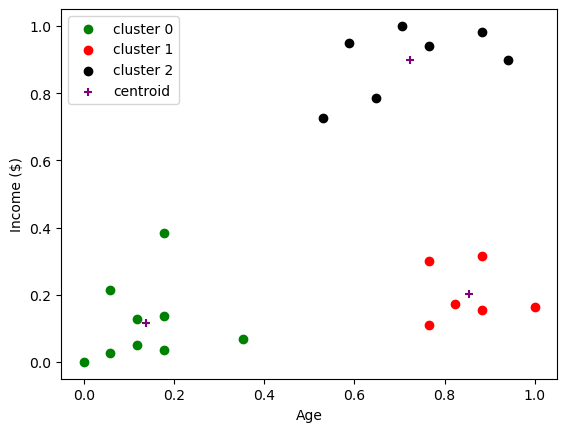

In [71]:
df1 = df[df['cluster_new'] == 0]
df2 = df[df['cluster_new'] == 1]
df3 = df[df['cluster_new'] == 2]
plt.scatter(df1.Age, df1['Income ($)'], color='green', label= 'cluster 0')
plt.scatter(df2.Age, df2['Income ($)'], color='red', label= 'cluster 1')
plt.scatter(df3.Age, df3['Income ($)'], color='black', label= 'cluster 2')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='purple', marker='+', label='centroid')

plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()

In [73]:
k_rng = range(1, 10)
sse = []
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age', 'Income ($)']])
    sse.append(km.inertia_)

C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

In [75]:
sse

[5.437019069482913,
 2.0918182013467015,
 0.47576016250293407,
 0.40251523555282465,
 0.2772119246773965,
 0.2346554743901918,
 0.18451349247936358,
 0.15678510170273696,
 0.11644308065063394]

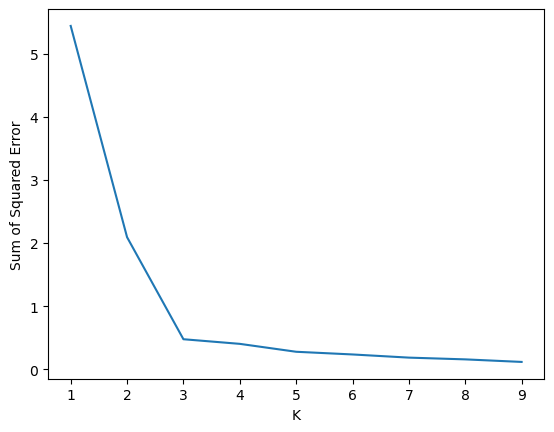

In [77]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng, sse)